In [1]:
import warnings

warnings.simplefilter(action='ignore', category=FutureWarning)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pingouin as pg
import scipy.stats as stats
import seaborn as sns

from multipred.plotting import barplot_morey, barplot_morey_maineffect

In [2]:
PROJECT_PATH = "/media/wiseman/tocho/multipred-fmri"
DATA_PATH = f"{PROJECT_PATH}/data"

# Loading and preparing data

In [3]:
# Loading dataframe
df = pd.read_csv(f"{DATA_PATH}/derivatives/behavioral_raw/main/group_maintask_data.csv")
# rename column "outcome" to "correct"
df.rename(columns={"outcome": "correct", "id": "subj"}, inplace=True)
# change values of v_pred column, o if VP 1 if EXP
df["v_pred"] = df["v_pred"].map({"VP": 0, "EXP": 1})
df["a_pred"] = df["a_pred"].map({"VP": 0, "EXP": 1})

df = df[df["subj"]!="sub-15"]
df = df[df["catch"]==0]

In [4]:
def RT_filter(df):
    # this function was used to filter those trials with a RT that are 3 standard deviations away from the mean
    rt_mean = df['RT'].mean()
    up_lim = rt_mean + 3 * df['RT'].std() # 
    x = df.loc[df['RT'] < up_lim, : ]
    return x #the same dataframe with RT filtered

In [5]:
df = df.groupby("subj").apply(RT_filter).reset_index(drop=True)

/tmp/ipykernel_326937/915597757.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("subj").apply(RT_filter).reset_index(drop=True)


## Effects of visual and auditory predictions

### Visual

,Source,ddof1,ddof2,F,p-unc,np2,eps
0,v_pred,1,24,1.114459,0.301626,0.044375,1.0


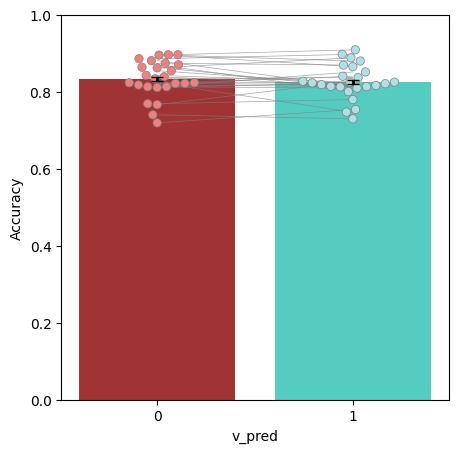

In [6]:
# Accuracy
dx = "v_pred"
dy = "correct"
id = "subj"
dat = df.groupby([id, dx], as_index=0)[dy].mean()

palette1 = ["firebrick", "turquoise"]; palette2 = ["lightcoral", "powderblue"]
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
barplot_morey_maineffect(dat, dx, dy, palette1, palette2, True, True, True, ax)
ax.set_ylim(0, 1)
ax.set_ylabel("Accuracy")
pg.rm_anova(dv=dy, within= [dx], subject=id,correction='auto', effsize = "np2", data=dat)

              Source        SS  ddof1  ddof2        MS         F     p-unc  \
0           modality  0.007279      1     24  0.007279  1.994378  0.170720   
1             v_pred  0.001325      1     24  0.001325  1.144071  0.295434   
2  modality * v_pred  0.001139      1     24  0.001139  0.549302  0.465794   

   p-GG-corr       np2  eps  
0   0.170720  0.076723  1.0  
1   0.295434  0.045501  1.0  
2   0.465794  0.022375  1.0  


/media/wiseman/tocho/multipred-fmri/.venv/lib/python3.10/site-packages/pingouin/pairwise.py:28: UserWarning: pairwise_ttests is deprecated, use pairwise_tests instead.
  warnings.warn("pairwise_ttests is deprecated, use pairwise_tests instead.", UserWarning)


,Contrast,modality,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges
0,modality,-,auditory,visual,True,True,-1.412225,24.0,two-sided,0.170720,NaN,NaN,0.509,-0.320333
1,v_pred,-,0,1,True,True,1.069612,24.0,two-sided,0.295434,NaN,NaN,0.352,0.155416
2,modality * v_pred,auditory,0,1,True,True,1.183238,24.0,two-sided,0.248304,0.496607,fdr_bh,0.394,0.231083
3,modality * v_pred,visual,0,1,True,True,0.048748,24.0,two-sided,0.961523,0.961523,fdr_bh,0.211,0.008757


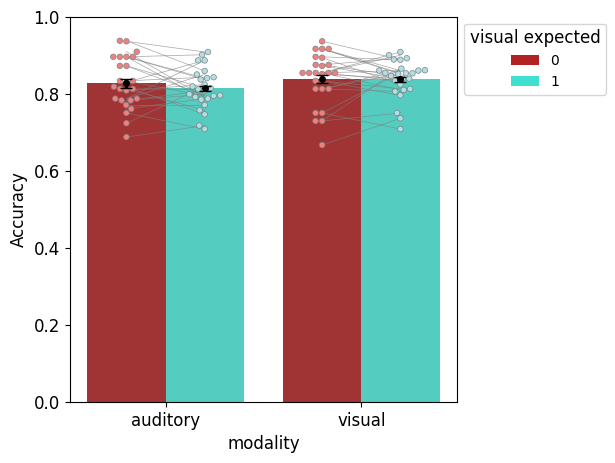

In [ ]:
# Accuracy, by attention
hue = "v_pred"
dx = "modality"
dy = "correct"
id = "subj"
dat = df.groupby([id, dx, hue], as_index=0)[dy].mean()

palette1 = ["firebrick", "turquoise"]; palette2 = ["lightcoral", "powderblue"]
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
barplot_morey(dat, dx, dy, hue, "visual expected", palette1, palette2, True, True, True, ax)
ax.set_ylim(0, 1)
ax.set_ylabel("Accuracy")
print(pg.rm_anova(dv=dy, within= [dx, hue], subject=id,correction='auto', effsize = "np2", data=dat))
pg.pairwise_ttests(dv=dy, within=[dx, hue], subject=id, data=dat, padjust='fdr_bh')

,Source,ddof1,ddof2,F,p-unc,np2,eps
0,v_pred,1,24,0.04692,0.830343,0.001951,1.0


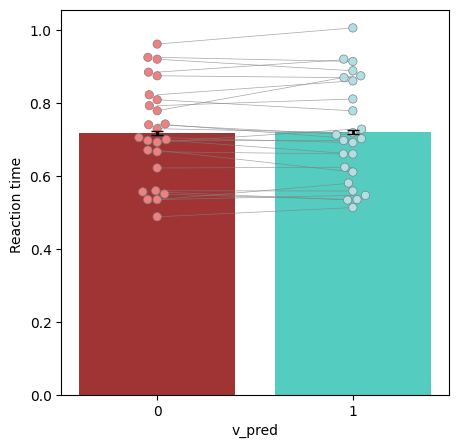

In [ ]:
#RT
dx = "v_pred"
dy = "RT"
id = "subj"
dat = df.groupby([id, dx], as_index=0)[dy].mean()

palette1 = ["firebrick", "turquoise"]; palette2 = ["lightcoral", "powderblue"]
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
barplot_morey_maineffect(dat, dx, dy, palette1, palette2, True, True, True, ax)
ax.set_ylabel("Reaction time ")
pg.rm_anova(dv=dy, within= [dx], subject=id,correction='auto', effsize = "np2", data=dat)

              Source        SS  ddof1  ddof2        MS          F     p-unc  \
0           modality  0.150510      1     24  0.150510  22.928410  0.000071   
1             v_pred  0.000051      1     24  0.000051   0.042564  0.838288   
2  modality * v_pred  0.005160      1     24  0.005160   6.064486  0.021354   

   p-GG-corr       np2  eps  
0   0.000071  0.488583  1.0  
1   0.838288  0.001770  1.0  
2   0.021354  0.201716  1.0  


/media/wiseman/tocho/multipred-fmri/.venv/lib/python3.10/site-packages/pingouin/pairwise.py:28: UserWarning: pairwise_ttests is deprecated, use pairwise_tests instead.
  warnings.warn("pairwise_ttests is deprecated, use pairwise_tests instead.", UserWarning)


,Contrast,modality,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges
0,modality,-,auditory,visual,True,True,4.788362,24.0,two-sided,0.000071,NaN,NaN,365.075,0.532227
1,v_pred,-,0,1,True,True,-0.206311,24.0,two-sided,0.838288,NaN,NaN,0.215,-0.010132
2,modality * v_pred,auditory,0,1,True,True,-1.658007,24.0,two-sided,0.110331,0.143419,fdr_bh,0.698,-0.098089
3,modality * v_pred,visual,0,1,True,True,1.512678,24.0,two-sided,0.143419,0.143419,fdr_bh,0.576,0.097421


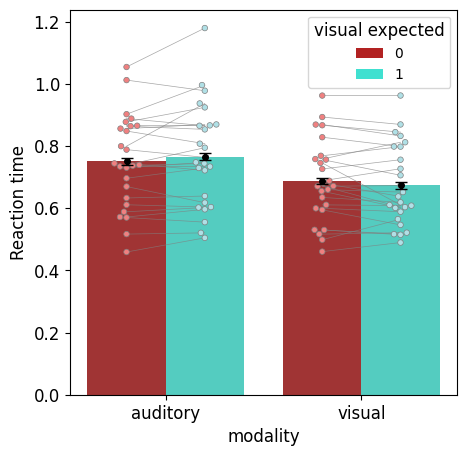

In [ ]:
# Accuracy, by attention
hue = "v_pred"
dx = "modality"
dy = "RT"
id = "subj"
dat = df.groupby([id, dx, hue], as_index=0)[dy].mean()

palette1 = ["firebrick", "turquoise"]; palette2 = ["lightcoral", "powderblue"]
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
barplot_morey(dat, dx, dy, hue, "visual expected", palette1, palette2, True, True, True, ax)
ax.set_ylabel("Reaction time")
print(pg.rm_anova(dv=dy, within= [dx, hue], subject=id,correction='auto', effsize = "np2", data=dat))
pg.pairwise_ttests(dv=dy, within=[dx, hue], subject=id, data=dat, padjust='fdr_bh')

### Auditory

,Source,ddof1,ddof2,F,p-unc,np2,eps
0,a_pred,1,24,0.173244,0.680944,0.007167,1.0


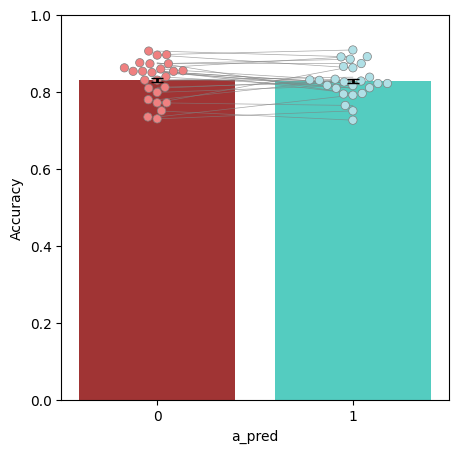

In [ ]:
# Accuracy
dx = "a_pred"
dy = "correct"
id = "subj"
dat = df.groupby([id, dx], as_index=0)[dy].mean()

palette1 = ["firebrick", "turquoise"]; palette2 = ["lightcoral", "powderblue"]
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
barplot_morey_maineffect(dat, dx, dy, palette1, palette2, True, True, True, ax)
ax.set_ylim(0, 1)
ax.set_ylabel("Accuracy")
pg.rm_anova(dv=dy, within= [dx], subject=id,correction='auto', effsize = "np2", data=dat)

              Source        SS  ddof1  ddof2        MS         F     p-unc  \
0           modality  0.011481      1     24  0.011481  3.548884  0.071757   
1             a_pred  0.000255      1     24  0.000255  0.169871  0.683885   
2  modality * a_pred  0.000088      1     24  0.000088  0.051156  0.822980   

   p-GG-corr       np2  eps  
0   0.071757  0.128821  1.0  
1   0.683885  0.007028  1.0  
2   0.822980  0.002127  1.0  


/media/wiseman/tocho/multipred-fmri/.venv/lib/python3.10/site-packages/pingouin/pairwise.py:28: UserWarning: pairwise_ttests is deprecated, use pairwise_tests instead.
  warnings.warn("pairwise_ttests is deprecated, use pairwise_tests instead.", UserWarning)


,Contrast,modality,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges
0,modality,-,auditory,visual,True,True,-1.883848,24.0,two-sided,0.071757,NaN,NaN,0.967,-0.406294
1,a_pred,-,0,1,True,True,0.412154,24.0,two-sided,0.683885,NaN,NaN,0.228,0.066048
2,modality * a_pred,auditory,0,1,True,True,0.112515,24.0,two-sided,0.911351,0.911351,fdr_bh,0.212,0.022050
3,modality * a_pred,visual,0,1,True,True,0.462594,24.0,two-sided,0.647822,0.911351,fdr_bh,0.233,0.083818


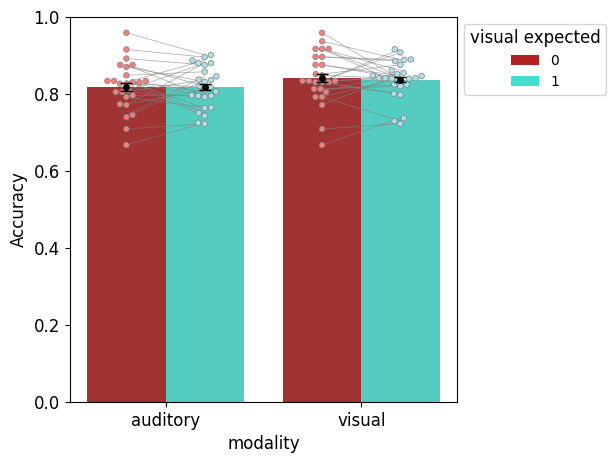

In [ ]:
# Accuracy, by attention
hue = "a_pred"
dx = "modality"
dy = "correct"
id = "subj"
dat = df.groupby([id, dx, hue], as_index=0)[dy].mean()

palette1 = ["firebrick", "turquoise"]; palette2 = ["lightcoral", "powderblue"]
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
barplot_morey(dat, dx, dy, hue, "visual expected", palette1, palette2, True, True, True, ax)
ax.set_ylim(0, 1)
ax.set_ylabel("Accuracy")
print(pg.rm_anova(dv=dy, within= [dx, hue], subject=id,correction='auto', effsize = "np2", data=dat))
pg.pairwise_ttests(dv=dy, within=[dx, hue], subject=id, data=dat, padjust='fdr_bh')

,Source,ddof1,ddof2,F,p-unc,np2,eps
0,a_pred,1,24,0.885721,0.356017,0.035592,1.0


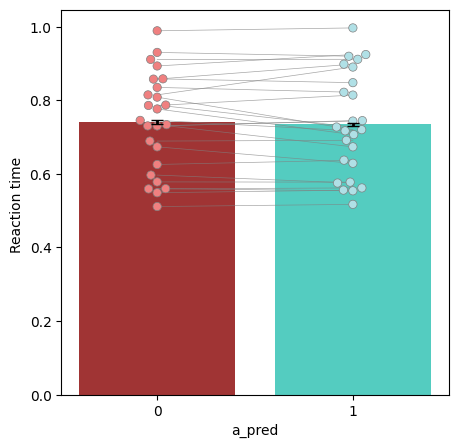

In [42]:
#RT
dx = "a_pred"
dy = "RT"
id = "subj"
dat = df.groupby([id, dx], as_index=0)[dy].mean()

palette1 = ["firebrick", "turquoise"]; palette2 = ["lightcoral", "powderblue"]
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
barplot_morey_maineffect(dat, dx, dy, palette1, palette2, True, True, True, ax)
ax.set_ylabel("Reaction time ")
pg.rm_anova(dv=dy, within= [dx], subject=id,correction='auto', effsize = "np2", data=dat)

              Source        SS  ddof1  ddof2        MS          F     p-unc  \
0           modality  0.248006      1     24  0.248006  31.732689  0.000008   
1             a_pred  0.001188      1     24  0.001188   0.885721  0.356017   
2  modality * a_pred  0.000064      1     24  0.000064   0.062343  0.804956   

   p-GG-corr       np2  eps  
0   0.000008  0.569373  1.0  
1   0.356017  0.035592  1.0  
2   0.804956  0.002591  1.0  


/media/wiseman/tocho/multipred-fmri/.venv/lib/python3.10/site-packages/pingouin/pairwise.py:28: UserWarning: pairwise_ttests is deprecated, use pairwise_tests instead.
  warnings.warn("pairwise_ttests is deprecated, use pairwise_tests instead.", UserWarning)


,Contrast,modality,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges
0,modality,-,auditory,visual,True,True,5.633178,24.0,two-sided,0.000008,NaN,NaN,2520.661,0.689396
1,a_pred,-,0,1,True,True,0.941127,24.0,two-sided,0.356017,NaN,NaN,0.314,0.049742
2,modality * a_pred,auditory,0,1,True,True,0.789293,24.0,two-sided,0.437669,0.543529,fdr_bh,0.28,0.053096
3,modality * a_pred,visual,0,1,True,True,0.616253,24.0,two-sided,0.543529,0.543529,fdr_bh,0.251,0.040143


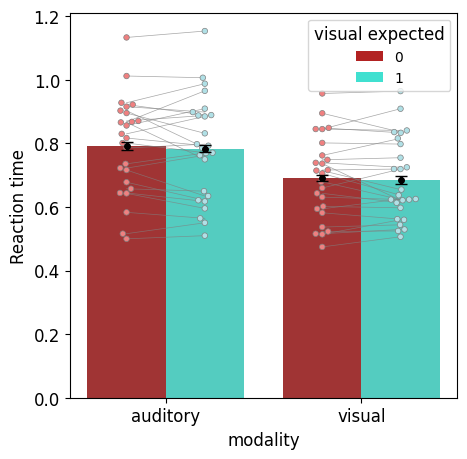

In [43]:
# Accuracy, by attention
hue = "a_pred"
dx = "modality"
dy = "RT"
id = "subj"
dat = df.groupby([id, dx, hue], as_index=0)[dy].mean()

palette1 = ["firebrick", "turquoise"]; palette2 = ["lightcoral", "powderblue"]
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
barplot_morey(dat, dx, dy, hue, "visual expected", palette1, palette2, True, True, True, ax)
ax.set_ylabel("Reaction time")
print(pg.rm_anova(dv=dy, within= [dx, hue], subject=id,correction='auto', effsize = "np2", data=dat))
pg.pairwise_ttests(dv=dy, within=[dx, hue], subject=id, data=dat, padjust='fdr_bh')

## Explicit recall phase

In [5]:
df_explicit = pd.read_csv((f'{DATA_PATH}/derivatives/behavioral_raw/training/group_explicit_data.csv'))
df_explicit.rename(columns={"outcome": "correct", "id": "subj"}, inplace=True)
dat = df_explicit[df_explicit.modality == "visual"]
k = dat["correct"].sum() # Number of correct recalls
n = len(dat) ; # Number of trials
stats.binomtest(k, n, p=0.5, alternative="two-sided") # higher than chance

BinomTestResult(k=153, n=208, alternative='two-sided', statistic=0.7355769230769231, pvalue=7.106913122896171e-12)

In [6]:
dat = df_explicit[df_explicit.modality == "auditory"]
k = dat["correct"].sum() # Number of correct recalls
n = len(dat) ; # Number of trials
stats.binomtest(k, n, p=0.5, alternative="two-sided") # higher than chance

BinomTestResult(k=113, n=208, alternative='two-sided', statistic=0.5432692307692307, pvalue=0.23843026889610858)

In [7]:
df_explicit.groupby(["modality"])["correct"].mean()

modality
auditory    0.543269
visual      0.735577
Name: correct, dtype: float64

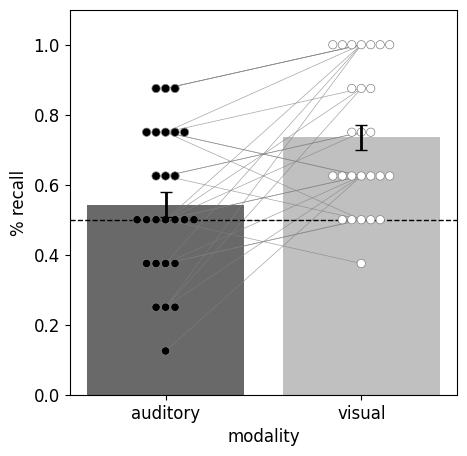

In [9]:
# Accuracy
dx = "modality"
dy = "correct"
id = "subj"
dat = df_explicit.groupby([id, dx], as_index=0)[dy].mean()

palette1 =["dimgray", "silver"]; palette2 = ["black", "white"]
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
barplot_morey_maineffect(dat, dx, dy, palette1, palette2, True, True, True, ax)
ax.set_ylim(0, 1.1)
ax.set_ylabel("% recall")
pg.rm_anova(dv=dy, within= [dx], subject=id,correction='auto', effsize = "np2", data=dat)
ax.axhline(y=.5, linestyle='--', color='black', linewidth=1)

## Relevant

In [65]:
att_learned_model = Lmer("correct ~ relevant_expected * att_learned * modality + (1|id)", data = df, family="binomial") 
att_learned_model.fit(factors={**relevant_expected, **att_learned, **modality})

Linear mixed model fit by maximum likelihood  ['lmerMod']
Formula: correct~relevant_expected*att_learned*modality+(1|id)

Family: binomial	 Inference: parametric

Number of observations: 9797	 Groups: {'id': 26.0}

Log-likelihood: -4557.766 	 AIC: 9133.532

Random effects:

           Name   Var  Std
id  (Intercept)  0.16  0.4

No random effect correlations specified

Fixed effects:



,Estimate,2.5_ci,97.5_ci,SE,OR,OR_2.5_ci,OR_97.5_ci,Prob,Prob_2.5_ci,Prob_97.5_ci,Z-stat,P-val,Sig
(Intercept),1.581,1.355,1.807,0.115,4.861,3.878,6.092,0.829,0.795,0.859,13.723,0.000,***
relevant_expected1,-0.112,-0.300,0.075,0.096,0.894,0.741,1.078,0.472,0.426,0.519,-1.175,0.240,
att_learned1,-0.102,-0.515,0.311,0.211,0.903,0.598,1.365,0.475,0.374,0.577,-0.482,0.630,
modality1,0.041,-0.218,0.301,0.132,1.042,0.804,1.351,0.510,0.446,0.575,0.313,0.754,
relevant_expected1:att_learned1,-0.038,-0.495,0.419,0.233,0.963,0.610,1.521,0.491,0.379,0.603,-0.161,0.872,
relevant_expected1:modality1,0.126,-0.169,0.421,0.150,1.134,0.845,1.523,0.531,0.458,0.604,0.838,0.402,
att_learned1:modality1,0.146,-0.371,0.663,0.264,1.157,0.690,1.940,0.536,0.408,0.660,0.553,0.580,
relevant_expected1:att_learned1:modality1,-0.069,-0.647,0.509,0.295,0.933,0.523,1.664,0.483,0.344,0.625,-0.234,0.815,


In [19]:
# # Load models
# att_learn1 = load_model("models/exp1/exp1_attlearn1.joblib") # correct ~ relevant_expected * att_learned + (1|id)
# att_learn2 = load_model("models/exp1/exp1_attlearn2.joblib") # correct ~ relevant_expected * att_learned + modality + (1|id)
# att_learn3 = load_model("models/exp1/exp1_attlearn3.joblib") # correct ~ relevant_expected * att_learned * modality + (1|id)
# att_learn4 = load_model("models/exp1/exp1_attlearn4.joblib") # correct ~ relevant_expected * att_learned + modality + (1 + modality|id)
# att_learn5 = load_model("models/exp1/exp1_attlearn5.joblib") # correct ~ relevant_expected * att_learned * modality + (1 + modality|id)

# # Compare models
# reportAIC([att_learn1, att_learn2, att_learn3, att_learn4, att_learn5])

# # Best model is model 2: correct~relevant_expected*att_learned+modality+(1|id)   AIC: 10904.50502144479 ||  BIC: 10948.91970482182
# # But model 3 allows control of modality 

Model 0: correct~relevant_expected*att_learned+(1|id)   AIC: 10986.769205216011 ||  BIC: 11023.781441363535
Model 1: correct~relevant_expected*att_learned+modality+(1|id)   AIC: 10904.50502144479 ||  BIC: 10948.91970482182
Model 2: correct~relevant_expected*att_learned*modality+(1|id)   AIC: 10905.608302882742 ||  BIC: 10972.230327948286
Model 3: correct~relevant_expected*att_learned+modality+(1+modality|id)   AIC: 10907.223633113503 ||  BIC: 10966.443210949543
Model 4: correct~relevant_expected*att_learned*modality+(1+modality|id)   AIC: 10908.355498513316 ||  BIC: 10989.78241803787


In [66]:
att_learned_model.coefs

,Estimate,2.5_ci,97.5_ci,SE,OR,OR_2.5_ci,OR_97.5_ci,Prob,Prob_2.5_ci,Prob_97.5_ci,Z-stat,P-val,Sig
(Intercept),1.581202,1.355368,1.807036,0.115224,4.860796,3.878189,6.092365,0.829375,0.795006,0.859003,13.722909,7.403461e-43,***
relevant_expected1,-0.112290,-0.299588,0.075008,0.095562,0.893785,0.741123,1.077893,0.471957,0.425658,0.518743,-1.175046,2.399761e-01,
att_learned1,-0.101575,-0.514632,0.311483,0.210748,0.903414,0.597720,1.365448,0.474628,0.374108,0.577247,-0.481973,6.298249e-01,
modality1,0.041355,-0.217813,0.300522,0.132231,1.042222,0.804276,1.350564,0.510337,0.445761,0.574570,0.312746,7.544740e-01,
relevant_expected1:att_learned1,-0.037620,-0.494620,0.419380,0.233168,0.963079,0.609803,1.521018,0.490596,0.378806,0.603335,-0.161343,8.718235e-01,
relevant_expected1:modality1,0.125961,-0.168809,0.420731,0.150395,1.134238,0.844671,1.523074,0.531449,0.457898,0.603658,0.837533,4.022929e-01,
att_learned1:modality1,0.145885,-0.371052,0.662822,0.263748,1.157063,0.690008,1.940259,0.536407,0.408287,0.659894,0.553122,5.801798e-01,
relevant_expected1:att_learned1:modality1,-0.069162,-0.647309,0.508985,0.294978,0.933175,0.523452,1.663602,0.482716,0.343596,0.624569,-0.234465,8.146240e-01,


In [67]:
att_learned_model.post_hoc(marginal_vars="relevant_expected", grouping_vars="att_learned")

(  relevant_expected att_learned  Estimate  2.5_ci  97.5_ci     SE   DF
 1                 0           0     1.602   1.399    1.804  0.103  inf
 2                 1           0     1.553   1.380    1.725  0.088  inf
 3                 0           1     1.573   1.302    1.845  0.139  inf
 4                 1           1     1.452   1.250    1.653  0.103  inf,
                                   Contrast att_learned  Estimate  2.5_ci  \
 1  relevant_expected0 - relevant_expected1           0     0.049  -0.098   
 2  relevant_expected0 - relevant_expected1           1     0.122  -0.127   
 
    97.5_ci     SE   DF  Z-stat  P-val Sig  
 1    0.197  0.075  inf   0.656  0.512      
 2    0.370  0.127  inf   0.960  0.337      )

In [68]:
dat = att_learned_model.post_hoc(marginal_vars="relevant_expected", grouping_vars="att_learned")[0]
errors = dat['Estimate'] - dat["2.5_ci"]; dat["errors"] = errors


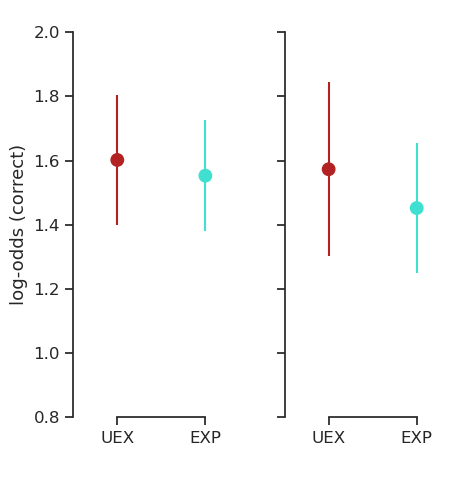

In [69]:
fig, ax = plt.subplots(1, 2, figsize=(5, 5), sharey=True)
dat[0:2].plot(x="relevant_expected", y='Estimate', kind='bar',
                 ax=ax[0], color = 'none', fontsize=12, 
                 ecolor=["firebrick", "turquoise"],capsize=0,
                 yerr="errors", legend=False)

ax[0].scatter(x=np.arange(dat[0:2].shape[0]),
            marker='o', s=80, 
            y=dat[0:2]['Estimate'],
            color=["firebrick", "turquoise"])


dat[2:4].plot(x="relevant_expected", y='Estimate', kind='bar',
                 ax=ax[1], color='none', fontsize=12, 
                 ecolor=["firebrick", "turquoise"],capsize=0,
                 yerr="errors", legend=False)

ax[1].scatter(x=np.arange(dat[2:4].shape[0]),
            marker='o', s=80, 
            y=dat[2:4]['Estimate'],
            color=["firebrick", "turquoise"])

ax[0].set_ylabel("log-odds (correct)", fontsize=13)
ax[0].set_xlabel(" ")
ax[0].set_xticklabels(labels = ["UEX", "EXP"], rotation=0)
ax[0].set_title(" ", fontsize=13)
ax[1].set_title(" ", fontsize=13)
ax[1].set_xlabel(" ")
ax[0].set(ylim=[.8, 2])
ax[1].set(ylim=[.8, 2])
ax[1].set_xticklabels(labels = ["UEX", "EXP"], rotation=0)
sns.despine(ax=ax[0], trim=True)
sns.despine(ax=ax[1], trim=True)
#plt.savefig("figures/exp1/att_recall.png", dpi=500, bbox_inches='tight')

## Unattended

In [70]:
ign_learned_model = Lmer("correct ~ irrelevant_expected * ign_learned * modality + (1|id)", data = df, family="binomial") 
ign_learned_model.fit(factors={**irrelevant_expected, **ign_learned, **modality})

Linear mixed model fit by maximum likelihood  ['lmerMod']
Formula: correct~irrelevant_expected*ign_learned*modality+(1|id)

Family: binomial	 Inference: parametric

Number of observations: 9797	 Groups: {'id': 26.0}

Log-likelihood: -4553.558 	 AIC: 9125.117

Random effects:

           Name    Var   Std
id  (Intercept)  0.152  0.39

No random effect correlations specified

Fixed effects:



,Estimate,2.5_ci,97.5_ci,SE,OR,OR_2.5_ci,OR_97.5_ci,Prob,Prob_2.5_ci,Prob_97.5_ci,Z-stat,P-val,Sig
(Intercept),1.688,1.431,1.946,0.131,5.410,4.182,6.997,0.844,0.807,0.875,12.857,0.000,***
irrelevant_expected1,-0.303,-0.533,-0.072,0.118,0.739,0.587,0.930,0.425,0.370,0.482,-2.574,0.010,*
ign_learned1,-0.114,-0.436,0.208,0.164,0.892,0.647,1.231,0.472,0.393,0.552,-0.693,0.488,
modality1,-0.018,-0.285,0.249,0.136,0.982,0.752,1.283,0.495,0.429,0.562,-0.133,0.894,
irrelevant_expected1:ign_learned1,0.198,-0.152,0.548,0.179,1.218,0.859,1.729,0.549,0.462,0.634,1.106,0.269,
irrelevant_expected1:modality1,0.204,-0.096,0.504,0.153,1.227,0.909,1.656,0.551,0.476,0.623,1.333,0.182,
ign_learned1:modality1,0.456,-0.106,1.018,0.287,1.578,0.900,2.767,0.612,0.474,0.735,1.592,0.111,
irrelevant_expected1:ign_learned1:modality1,-0.474,-1.095,0.147,0.317,0.623,0.334,1.159,0.384,0.251,0.537,-1.495,0.135,


In [31]:
# # Load models
# ign_learn1 = load_model("models/exp1/exp1_ignlearn1.joblib") # correct ~ irrelevant_expected * ign_learned + (1|id)
# ign_learn2 = load_model("models/exp1/exp1_ignlearn2.joblib") # correct ~ irrelevant_expected * ign_learned + modality + (1|id)
# ign_learn3 = load_model("models/exp1/exp1_ignlearn3.joblib") # correct ~ irrelevant_expected * ign_learned * modality + (1|id)
# ign_learn4 = load_model("models/exp1/exp1_ignlearn4.joblib") # correct ~ irrelevant_expected * ign_learned + modality + (1 + modality|id)
# ign_learn5 = load_model("models/exp1/exp1_ignlearn5.joblib") # correct ~ irrelevant_expected * ign_learned * modality + (1 + modality|id)

# # Compare models
# reportAIC([ign_learn1, ign_learn2, ign_learn3, ign_learn4, ign_learn5])

# # Best model is model 2: correct~irrelevant_expected*ign_learned+modality+(1|id)   AIC: 10957.793581120013 ||  BIC: 11002.208264497043
# # But model 3 allows control of modality and compare with attended model

Model 0: correct~irrelevant_expected*ign_learned+(1|id)   AIC: 11037.920972421998 ||  BIC: 11074.933208569522
Model 1: correct~irrelevant_expected*ign_learned+modality+(1|id)   AIC: 10957.793581120013 ||  BIC: 11002.208264497043
Model 2: correct~irrelevant_expected*ign_learned*modality+(1|id)   AIC: 10962.305160254733 ||  BIC: 11028.927185320277
Model 3: correct~irrelevant_expected*ign_learned+modality+(1+modality|id)   AIC: 10960.059330570271 ||  BIC: 11019.278908406312
Model 4: correct~irrelevant_expected*ign_learned*modality+(1+modality|id)   AIC: 10964.539396959797 ||  BIC: 11045.966316484351


In [71]:
ign_learned_model.coefs

,Estimate,2.5_ci,97.5_ci,SE,OR,OR_2.5_ci,OR_97.5_ci,Prob,Prob_2.5_ci,Prob_97.5_ci,Z-stat,P-val,Sig
(Intercept),1.688176,1.430818,1.945535,0.131308,5.409606,4.182117,6.997373,0.843984,0.807029,0.874959,12.856632,7.894241e-38,***
irrelevant_expected1,-0.302580,-0.532977,-0.072184,0.117552,0.738909,0.586855,0.930360,0.424927,0.369823,0.481962,-2.574023,1.005237e-02,*
ign_learned1,-0.113792,-0.435664,0.208081,0.164224,0.892444,0.646835,1.231312,0.471583,0.392775,0.551833,-0.692907,4.883680e-01,
modality1,-0.018131,-0.285369,0.249108,0.136349,0.982033,0.751737,1.282880,0.495467,0.429138,0.561957,-0.132973,8.942146e-01,
irrelevant_expected1:ign_learned1,0.197568,-0.152394,0.547529,0.178555,1.218435,0.858650,1.728976,0.549232,0.461975,0.633562,1.106480,2.685190e-01,
irrelevant_expected1:modality1,0.204224,-0.095951,0.504398,0.153153,1.226573,0.908509,1.655989,0.550879,0.476031,0.623492,1.333462,1.823803e-01,
ign_learned1:modality1,0.456127,-0.105587,1.017841,0.286594,1.577950,0.899796,2.767213,0.612095,0.473628,0.734552,1.591542,1.114876e-01,
irrelevant_expected1:ign_learned1:modality1,-0.473996,-1.095271,0.147279,0.316983,0.622510,0.334449,1.158678,0.383671,0.250627,0.536753,-1.495335,1.348271e-01,


In [72]:
dat = ign_learned_model.post_hoc(marginal_vars="irrelevant_expected", grouping_vars="ign_learned")[0]
errors = dat['Estimate'] - dat["2.5_ci"]; dat["errors"] = errors


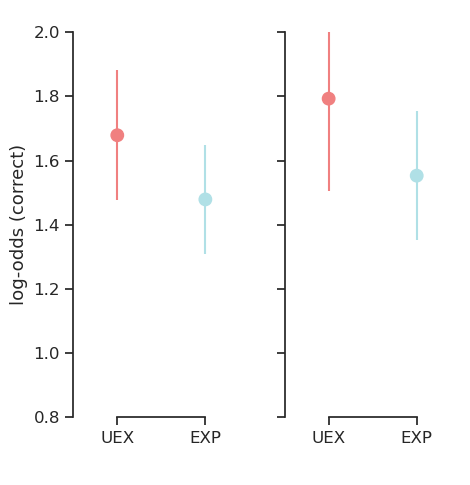

In [73]:
fig, ax = plt.subplots(1, 2, figsize=(5, 5), sharey=True)
dat[0:2].plot(x="irrelevant_expected", y='Estimate', kind='bar',
                 ax=ax[0], color = 'none', fontsize=12, 
                 ecolor=["lightcoral", "powderblue"],capsize=0,
                 yerr="errors", legend=False)

ax[0].scatter(x=np.arange(dat[0:2].shape[0]),
            marker='o', s=80, 
            y=dat[0:2]['Estimate'],
            color=["lightcoral", "powderblue"])


dat[2:4].plot(x="irrelevant_expected", y='Estimate', kind='bar',
                 ax=ax[1], color='none', fontsize=12, 
                 ecolor=["lightcoral", "powderblue"],capsize=0,
                 yerr="errors", legend=False)

ax[1].scatter(x=np.arange(dat[2:4].shape[0]),
            marker='o', s=80, 
            y=dat[2:4]['Estimate'],
            color=["lightcoral", "powderblue"])

ax[0].set_ylabel("log-odds (correct)", fontsize=13)
ax[0].set_xlabel(" ")
ax[0].set_xticklabels(labels = ["UEX", "EXP"], rotation=0)
ax[0].set_title(" ", fontsize=13)
ax[1].set_title(" ", fontsize=13)
ax[1].set_xlabel(" ")
ax[0].set(ylim=[.8, 2])
ax[1].set(ylim=[.8, 2])
ax[1].set_xticklabels(labels = ["UEX", "EXP"], rotation=0)
sns.despine(ax=ax[0], trim=True)
sns.despine(ax=ax[1], trim=True)
#plt.savefig("figures/exp1/ign_recall.png", dpi=500, bbox_inches='tight')